# 09 練習問題 解答 — partnered vs unpartnered
対象: [`notebooks/09_partnered_vs_unpartnered.ipynb`](../notebooks/09_partnered_vs_unpartnered.ipynb)

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, matplotlib.pyplot as plt
from ecell4 import run_simulation
from ecell4_base.core import NetworkModel, ReactionRule, Species
H = Species('H'); BETA,KD = 1.0,1.0
def R(a,b,k): return ReactionRule(a,b,k)
def pair(i, a_s, a_m, ka=1.0, k5=10.0):
    s,m,sH,mH,T,D = (Species(f'{x}{i}') for x in ['s','m','sH','mH','T','D'])
    return [R([],[s],a_s),R([],[m],a_m),R([s],[],BETA),R([m],[],BETA),
            R([s,H],[sH],ka),R([sH],[s,H],KD),R([m,H],[mH],ka),R([mH],[m,H],KD),
            R([sH,m],[T],ka),R([T],[sH,m],KD),R([mH,s],[T],ka),R([T],[mH,s],KD),
            R([T],[D,H],k5),R([sH],[H],BETA),R([mH],[H],BETA),R([T],[H],BETA),R([D],[],BETA)]
NAMES=['H']+[f'{x}{i}' for i in (1,2) for x in ['s','m','sH','mH','T','D']]
MODES={'sRNA_only':(1.,0.),'mRNA_only':(0.,1.),'partnered':(1.,1.)}
def reporter(load, mode, ka=1.0, k5=10.0, h_tot=12.0):
    fs,fm=MODES[mode]; mdl=NetworkModel()
    for r in pair(1, fs*load, fm*load, ka, k5)+pair(2,10.,10.,1.0,10.0): mdl.add_reaction_rule(r)
    v=dict(zip(NAMES, run_simulation(600.,y0={'H':h_tot},model=mdl,solver='ode',ndiv=1,species_list=NAMES).as_array()[-1][1:]))
    tot=v['m2']+v['mH2']+v['T2']+v['D2']; return 100*v['D2']/tot if tot>0 else 0.0

## Q1. partnered でも duplex 形成 `k5` を遅くすると、妨害は unpartnered に近づく?

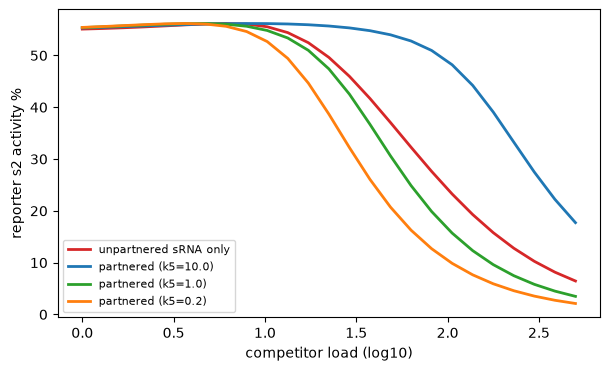

In [2]:
load=np.logspace(0,2.7,25); fig,ax=plt.subplots(figsize=(7,4))
ax.plot(np.log10(load),[reporter(a,'sRNA_only') for a in load],'C3',lw=2,label='unpartnered sRNA only')
for k5,c in [(10.0,'C0'),(1.0,'C2'),(0.2,'C1')]:
    ax.plot(np.log10(load),[reporter(a,'partnered',k5=k5) for a in load],color=c,lw=2,label=f'partnered (k5={k5})')
ax.set_xlabel('competitor load (log10)'); ax.set_ylabel('reporter s2 activity %'); ax.legend(fontsize=8); plt.show()

**答**: partnered でも `k5` を遅くする（Hfq をなかなか返さない）と、妨害が強まり **unpartnered に近づく**。partnered が妨害しにくいのは「duplex を作って Hfq を素早く返すから」なので、その返却を止めると利点が消える。Hfq recycling の速さが partnered の鍵。

## Q2. 競合 sRNA の Hfq 結合を強める（`ka`↑）と partnered/unpartnered 差は?

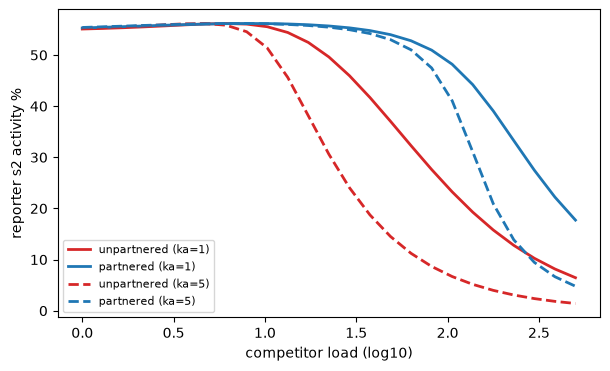

In [3]:
fig,ax=plt.subplots(figsize=(7,4))
for ka,ls in [(1.0,'-'),(5.0,'--')]:
    ax.plot(np.log10(load),[reporter(a,'sRNA_only',ka=ka) for a in load],'C3',ls=ls,lw=2,label=f'unpartnered (ka={ka:.0f})')
    ax.plot(np.log10(load),[reporter(a,'partnered',ka=ka) for a in load],'C0',ls=ls,lw=2,label=f'partnered (ka={ka:.0f})')
ax.set_xlabel('competitor load (log10)'); ax.set_ylabel('reporter s2 activity %'); ax.legend(fontsize=8); plt.show()

**答**: 競合の Hfq 結合を強める（ka=5）と、**unpartnered の妨害はさらに強まる**（Hfq を強く抱え込む）。partnered は結合が強くても duplex で返すので相対的に影響が小さく、**partnered/unpartnered の差が広がる**。「強く結合する片割れ」を単独発現するのが最悪、という含意。

## Q3.（考察）レポーターが「活性化型」でも同じ結論か

**答（考察）**: 活性化型 sRNA（duplex 形成が標的 mRNA を安定化/翻訳促進する）でも、**律速は同じ「Hfq へのアクセス」**。unpartnered な競合が Hfq を隔離すれば、活性化 sRNA も標的 mRNA と Hfq 上で出会えず、活性化が損なわれる。抑制型で「%duplex 低下」だったものが活性化型では「標的発現の増加が起きない」に読み替わるだけで、**partnered が妨害しにくい／unpartnered が妨害するという結論は共通**（Hfq 隔離がボトルネックだから）。

## Q4.（考察）bio-a: partnered/unpartnered とゲノム文脈

**答（考察）**: 標的と近接して（同じオペロン/隣接領域で）共発現される sRNA は事実上 partnered に近く Hfq を隔離しにくい。一方、ストレスで単独強誘導される sRNA は unpartnered として振る舞い Hfq を奪う。オーソログ/系統間で sRNA と標的の**ゲノム配置・共発現の有無**に違いがあれば、Hfq プールへの負荷（＝他経路への副作用）が変わると予測できる。ゲノム文脈と partnered/unpartnered の対応は bio-e / bio-a の配列・座位情報と結びつけて検討する。